## Problem Description

The problem I will attempt to solve is recreating a spam filter that can be applied to my Outlook email accounts, which have historically misclassified important emails and promotional emails — compared to Gmail's filtering mechanisms which had served me well. I will attempt to create a classifier model to determine which emails require a reply and which don't, and also to classify promotional emails for auto-archiving.

## Dataset

The data for this project comes from my personal Gmail archives, exported via [Google Takeout](https://takeout.google.com/) as `.mbox` files. I have two Gmail accounts:

The first account is from Econverse (`econverse.org`), a company I co-founded where I served as VP for Finance & Operations — it contains approximately 3 years of business correspondence primarily in Polish, with some conversations in English, Czech, German, and Slovak — 14,748 messages. The second is my Minerva University student account, primarily in English, which I use for my personal correspondence, academic-related ones, and also related to AI Consensus — 21,528 messages.

Together the two exports contain over 36,000 emails, of which approximately 3,200 are sent messages and the remaining ~33,000 are incoming. Only incoming emails are used for classification; sent emails are excluded from the dataset but are used during labeling to identify which incoming emails triggered a reply.

The benefit of using Gmail archives is that they already contain labels and thread IDs, and base labels such as Sent and Promotions, which makes it easier to create the dataset and conduct supervised learning.

## Classifier outcomes

The goal is to build a classifier that predicts whether an incoming email requires a reply from me. We define three classes:

| Class | Definition |
|-------|------------|
| `needs_reply` | The specific incoming email that chronologically triggered a sent reply from me |
| `no_reply` | An incoming email I did not reply to |
| `promotional` | Marketing / promotional email (identified by Gmail labels) |

Spam and outgoing (sent) emails are excluded from the dataset.

## Labeling strategy

In order to create labels for emails requiring replies, we use a trigger-based labeling approach: only the single incoming email that directly preceded my sent reply within the same thread is labeled `needs_reply`. This is more precise than labeling the entire thread, as it avoids inflating the positive class with emails that happened to be part of a replied-to thread but were not the actual trigger.

## Libraries used

In this project I will use standard liberies for data processing, manipulation and visualizaiton such as panadas, numpy, and scipy. For model training and evaluation I will use scikit-learn.


In [55]:
!pip install pandas scikit-learn numpy scipy matplotlib beautifulsoup4 -q

# Data Ingestion

This section loads the raw `.mbox` files extracted from Gmail via Google Takeout into a Pandas DataFrame. The mbox format stores all emails concatenated in a single file, which Python's built-in `mailbox` module can parse natively. Key steps:

1. MIME decoding — subject lines and Gmail labels may be MIME-encoded (e.g. `=?UTF-8?Q?...?=`); we decode them with `email.header.decode_header`.
2. Body extraction — emails can contain both `text/plain` and `text/html` parts. We prefer HTML (parsed via BeautifulSoup) because it handles formatting better; if HTML parsing fails, we fall back to plain text. The main reason to use HTML over plain text is that there are cases where the plain text body has a leakage of HTML tags, which makes it harder to clean for vectorization — doing our own HTML cleaning gives us more control over processing.
3. Metadata — we extract thread ID, labels, sender, recipients, date, and whether a `List-Unsubscribe` header is present.
4. HTML features — during body extraction we also record whether the body came from HTML and the ratio of markup to visible text.
5. Label decoding — Gmail labels (e.g. "Wysłano (sent)", "Skrzynka odbiorcza (Inbox)") are also MIME-encoded; we decode them here so they're ready for the labeling step in Section 3.

In [75]:
import mailbox
import pandas as pd
import numpy as np
import re
from email.header import decode_header
from email.utils import parsedate_to_datetime
from datetime import timezone
from bs4 import BeautifulSoup

MBOX_PATHS = [
    "data/Takeout EV/Poczta/Cała poczta, w tym Spam i Kosz.mbox",
    "data/Takeout MU/Mail/All mail Including Spam and Trash.mbox",
]


def decode_subject(subject):
    """Decode a MIME-encoded subject line into a plain string."""
    if not subject:
        return ""
    # Subject lines in mbox can be MIME-encoded (e.g. =?UTF-8?Q?...?=),
    # especially for Polish characters. decode_header splits them into
    # (bytes, encoding) pairs that we need to reassemble into one string.
    parts = decode_header(subject)
    decoded = []
    for p, enc in parts:
        if isinstance(p, bytes):
            try:
                decoded.append(p.decode(enc or "utf-8", errors="ignore"))
            except (LookupError, TypeError):
                # Some emails declare bogus encodings; latin-1 never fails
                decoded.append(p.decode("latin-1", errors="ignore"))
        else:
            decoded.append(p)
    return "".join(decoded)


def _decode_part(part):
    """Decode a single MIME part's payload into a string."""
    # Each MIME part carries its own charset declaration; we use it to
    # decode the raw bytes, falling back to utf-8 when it's missing.
    raw = part.get_payload(decode=True)
    if not raw:
        return ""
    return raw.decode(part.get_content_charset() or "utf-8", errors="ignore")


def extract_body(msg):
    """Extract body text, preferring HTML. Returns (text, html_processed, html_ratio)."""
    # Walk through all MIME parts and grab the first HTML and plain-text parts.
    # We prefer HTML because plain text sometimes leaks raw HTML tags, and
    # doing our own HTML-to-text conversion with BeautifulSoup gives us
    # cleaner output for vectorization.
    html_part = None
    plain_part = None
    for part in msg.walk():
        ctype = part.get_content_type()
        if ctype == "text/html" and not html_part:
            html_part = part
        elif ctype == "text/plain" and not plain_part:
            plain_part = part

    if html_part:
        try:
            raw_html = _decode_part(html_part)
            soup = BeautifulSoup(raw_html, "html.parser")
            # Remove style/script tags so they don't pollute the visible text
            for tag in soup(["style", "script"]):
                tag.decompose()
            text = soup.get_text(separator=" ")
            # html_ratio = fraction of the raw HTML that was markup (not visible text).
            # High ratio means the email was mostly formatting/templates (typical of promos).
            raw_len = len(raw_html)
            ratio = max(0.0, 1.0 - len(text) / raw_len) if raw_len > 0 else 0.0
            return text, True, ratio
        except Exception:
            pass

    # Fall back to plain text if HTML parsing failed or wasn't available
    return (_decode_part(plain_part) if plain_part else ""), False, 0.0


def parse_mbox(path):
    """Parse an mbox file into a list of record dicts."""
    records = []
    for msg in mailbox.mbox(path):
        try:
            date = parsedate_to_datetime(msg["date"]) if msg["date"] else None
        except Exception:
            date = None
        body_text, html_processed, html_ratio = extract_body(msg)
        records.append({
            "thread_id":       msg.get("X-GM-THRID", ""),
            "labels":          msg.get("X-Gmail-Labels", ""),
            "subject":         decode_subject(msg.get("subject", "")),
            "from":            msg.get("from", ""),
            "to":              msg.get("to", ""),
            "cc":              msg.get("cc", ""),
            "date":            date,
            "body":            body_text,
            "has_unsubscribe": "List-Unsubscribe" in msg.keys(),
            "html_processed":  html_processed,
            "html_ratio":      html_ratio,
        })
    return pd.DataFrame(records)


def decode_label(label):
    """Decode a MIME-encoded Gmail label string."""
    # Same MIME decoding as subjects — labels like "Wysłano" (Sent) come
    # encoded in the mbox and need to be decoded before we can match them.
    if not label:
        return ""
    try:
        parts = decode_header(label)
        decoded = []
        for p, enc in parts:
            if isinstance(p, bytes):
                try:
                    decoded.append(p.decode(enc or "utf-8", errors="ignore"))
                except (LookupError, TypeError):
                    decoded.append(p.decode("latin-1", errors="ignore"))
            else:
                decoded.append(p)
        return "".join(decoded)
    except Exception:
        return label


dfs = [parse_mbox(p) for p in MBOX_PATHS]
df_raw = pd.concat(dfs, ignore_index=True)
df_raw["labels_decoded"] = df_raw["labels"].apply(decode_label)
print(f"Messages loaded: {len(df_raw)}")

print("\n decode_subject examples")
for s in df_raw["subject"].dropna().head(4).tolist():
    print(f"  → {s[:300]}")

print("\n extract_body examples")
for _, row in df_raw[df_raw["body"].str.len() > 100].head(3).iterrows():
    print(f"  Subject : {row['subject'][:100]}")
    print(f"  Body    : {row['body'][:300].strip()}")
    print(f"  HTML?   : {row['html_processed']}  |  Ratio: {row['html_ratio']:.2f}")
    print()

Messages loaded: 36276

 decode_subject examples
  → Plany na luty? Jedziemy!❤️🎭❄️
  → ⭐️ [Jan 22nd] Bond AI SF - Upcoming AI events in SF
  → Important: Offer to purchase Econverse.Org
  → Skorzystaj z vouchera Uber* o wartości 60 zł PLN, dopóki jest dostępny

 extract_body examples
  Subject : Plany na luty? Jedziemy!❤️🎭❄️
  Body    : Wyjazd do spa we dwoje, szaleństwo na stoku czy wypad ze znajomymi? Wykorzystaj luty na maksa!͏‌ ͏‌ ͏ ͏‌ ͏‌ ͏ ‌ ͏‌ ͏‌ ͏ ‌ ͏‌ ͏‌ ͏ ‌ ͏‌ ͏‌ ͏ ‌ ͏‌ ͏‌ ͏ ‌ ͏‌ ͏‌ ͏ ‌ ͏‌ ͏‌ ͏ ‌ ͏‌ ͏‌ ͏‌  ͏‌ ͏‌ ͏‌  ͏‌ ͏‌ ͏‌ ͏ ‌ ͏‌ ͏‌ ͏‌  ͏‌ ͏‌ ͏‌  ͏‌ ͏‌ ͏‌ ͏ ‌ ͏‌ ͏‌ ͏‌
  HTML?   : True  |  Ratio: 0.96

  Subject : ⭐️ [Jan 22nd] Bond AI SF - Upcoming AI events in SF
  Body    : Bond AI SF - the only independent, curated community featuring in-person events, making it the… Bond AI - San Francisco and Bay Area ⭐️ [Jan 22nd] Bond AI SF - Upcoming AI events in SF ​​​​ Bond AI SF  - the only independent, curated community featuring in-person events, making it the ultimate
  HTML?  

# Pre-processing & Feature Engineering

## Label assignment

Gmail labels were already MIME-decoded during ingestion. Here we apply trigger-based labeling - only the single incoming email that chronologically preceded a sent reply in the same thread receives the `needs_reply` label. The raw trigger-based labeling can misclassify automated system emails (bounce notices, email-tracking reminders, noreply addresses, calendar notifications) as `needs_reply` when they happen to be the last incoming message before a sent reply. We filter these out using sender-address pattern matching and the `List-Unsubscribe` header, which removes ~10% of false positives from the `needs_reply` class. 


In [ ]:
# labels_decoded was already created during ingestion (Section 2)
df_raw["date_utc"] = pd.to_datetime(df_raw["date"], utc=True, errors="coerce")
df_raw_sorted = df_raw.sort_values("date_utc").reset_index(drop=True)

sent_mask = df_raw_sorted["labels_decoded"].str.contains("Sent|Wysłano", na=False)
sent_emails = df_raw_sorted[sent_mask]

# Automated / system sender patterns that should not be labeled needs_reply.
# These are bounce notices, email-tracking tools, noreply addresses, etc.
# that land in threads but are not real human emails worth replying to.
# By filtering them out during candidate selection, the actual human email
# that preceded the automated one can become the trigger instead.
AUTO_SENDER_PATTERNS = [
    "noreply", "no-reply", "no_reply",
    "mailer-daemon", "postmaster",
    "donotreply", "do-not-reply", "do_not_reply",
    "notifications@", "notification@",
    "reminders@", "reminder@",
    "calendar-notification",
    "forms-receipts-noreply",
    "bounce",
]

def _is_automated_sender(from_addr):
    """Return True if the sender matches a known automated/system pattern."""
    if not isinstance(from_addr, str):
        return False
    lower = from_addr.lower()
    return any(pat in lower for pat in AUTO_SENDER_PATTERNS)

# Pre-compute a mask for automated senders to exclude from trigger candidates
auto_mask = df_raw_sorted["from"].apply(_is_automated_sender) | df_raw_sorted["has_unsubscribe"]

reply_trigger_indices = set()
for _, sent in sent_emails.iterrows():
    if pd.isna(sent["date_utc"]):
        continue
    candidates = df_raw_sorted[
        (df_raw_sorted["thread_id"] == sent["thread_id"])
        & (~sent_mask)
        & (~auto_mask)
        & (df_raw_sorted["date_utc"].notna())
        & (df_raw_sorted["date_utc"] < sent["date_utc"])
    ]
    if len(candidates) > 0:
        reply_trigger_indices.add(candidates.index[-1])


def assign_label(row):
    labels = row["labels_decoded"]
    if "Spam" in labels:
        return "spam"
    if "Category Promotions" in labels or "Kategoria: promocje" in labels:
        return "promotional"
    if "Sent" in labels or "Wysłano" in labels:
        return None
    if row.name in reply_trigger_indices:
        return "needs_reply"
    return "no_reply"


df_raw_sorted["label"] = df_raw_sorted.apply(assign_label, axis=1)

df = df_raw_sorted[df_raw_sorted["label"].notna()].copy()
df = df[df["body"].str.len() > 20].copy()
df = df[df["label"] != "spam"].copy()

## Text cleaning

The `clean_text` function normalises email text for tokenization by:
- Replacing social-media profile URLs with specific tokens (`LINKEDIN_PROFILE`, `TWITTER_PROFILE`, `FACEBOOK_PROFILE`)
- Replacing remaining URLs and email addresses with generic tokens (`URL`, `EMAIL`)
- Replacing phone numbers with a `PHONE_NUMBER` token
- Replacing email signatures — via the standard `-- ` delimiter and a heuristic that catches common closing phrases (e.g. "Best regards", "Pozdrawiam") — with a `SIGNATURE` token
- Stripping residual HTML tags (safety net for edge cases where HTML leaks through)
- Keeping only Latin letters and Polish diacritical characters
- Lowercasing and collapsing whitespace

The reason for this is to allow the model to generalize from the training data to unseen emails, and to reduce the dimensionality of the feature space. For instance a we treat phone number presence as a signal for a reply, but we do not want the model to learn the specific phone number.

## Structural features

We also create addtional features which should provide addtional information to the model

| Feature | Type | Description |
|---------|------|-------------|
| `is_directly_to_me` | binary | Whether my email address appears in the `To:` field (vs only being CC'd or BCC'd) |
| `is_cc` | binary | Whether the email has a non-empty `Cc:` field (i.e. was sent to multiple people) |
| `has_unsubscribe` | binary | Whether a `List-Unsubscribe` header is present |
| `body_length` | int | Word count of the cleaned body |
| `link_count` | int | Number of URLs in the original body |
| `is_reply_chain` | binary | Whether the subject starts with `Re:` |
| `html_processed` | binary | Whether the body was extracted from an HTML part |
| `html_ratio` | float | Fraction of raw HTML that was markup (0.0–1.0) |
| `has_signature` | binary | Whether the cleaned body contains a signature-related token (SIGNATURE, PHONE_NUMBER, LINKEDIN_PROFILE, etc.) |

In [84]:
# Pre-compile all regexes so they aren't recompiled on every call (~65k times).
# The quoted-reply patterns use ^.*? (MULTILINE) instead of [^\n]* to avoid
# catastrophic backtracking on very long lines from HTML-extracted bodies.
_RE_LINKEDIN   = re.compile(r'https?://(?:www\.)?linkedin\.com/\S*', re.IGNORECASE)
_RE_TWITTER    = re.compile(r'https?://(?:www\.)?(?:twitter|x)\.com/\S*', re.IGNORECASE)
_RE_FACEBOOK   = re.compile(r'https?://(?:www\.)?facebook\.com/\S*', re.IGNORECASE)
_RE_URL        = re.compile(r'http\S+')
_RE_EMAIL_ADDR = re.compile(r'\S+@\S+')
_RE_PHONE_INTL = re.compile(r'\+\d{1,3}[\s\-.]?\d{2,4}[\s\-.]?\d{2,4}[\s\-.]?\d{2,4}[\s\-.]?\d{0,4}')
_RE_PHONE_US   = re.compile(r'\(?\d{3}\)?[\s\-.]?\d{3}[\s\-.]?\d{4}')
_RE_SIG_SEP    = re.compile(r'\n-- ?\n')
_RE_SIG_PHRASE = re.compile(
    r'(?m)^\s*(?:(?:best|kind|warm)\s+regards|pozdrawiam|z\s+poważaniem'
    r'|z\s+wyrazami\s+szacunku|sent\s+from\s+my|get\s+outlook'
    r'|cheers|sincerely|with\s+appreciation)',
    re.IGNORECASE,
)
_RE_QR_PL      = re.compile(r'^.*?napisa[łl]\(a\)\s*:', re.MULTILINE)
_RE_QR_EN      = re.compile(r'^.*?wrote\s*:', re.MULTILINE)
_RE_NAME_FULL  = re.compile(r'\bhubert\s+pysk[łl]o\b', re.IGNORECASE)
_RE_NAME_FIRST = re.compile(r'\bhubert\b', re.IGNORECASE)
_RE_NAME_LAST  = re.compile(r'\bpysk[łl]o\b', re.IGNORECASE)
_RE_NON_ALPHA  = re.compile(r'[^a-zA-Z\s\u00C0-\u017F]')
_RE_MULTI_WS   = re.compile(r'\s+')

def clean_text(text):
    """Normalise email text for TF-IDF vectorisation."""
    text = _RE_LINKEDIN.sub(' LINKEDIN_PROFILE ', text)
    text = _RE_TWITTER.sub(' TWITTER_PROFILE ', text)
    text = _RE_FACEBOOK.sub(' FACEBOOK_PROFILE ', text)
    text = _RE_URL.sub(' URL ', text)
    text = _RE_EMAIL_ADDR.sub(' EMAIL ', text)
    text = _RE_PHONE_INTL.sub(' PHONE_NUMBER ', text)
    text = _RE_PHONE_US.sub(' PHONE_NUMBER ', text)

    sig_sep = _RE_SIG_SEP.search(text)
    if sig_sep:
        text = text[:sig_sep.start()] + ' SIGNATURE '

    _sig = _RE_SIG_PHRASE.search(text)
    if _sig:
        text = text[:_sig.start()] + ' SIGNATURE '

    _qr = _RE_QR_PL.search(text) or _RE_QR_EN.search(text)
    if _qr:
        text = text[:_qr.start()] + ' QUOTED_REPLY '

    text = _RE_NAME_FULL.sub(' MY_NAME ', text)
    text = _RE_NAME_FIRST.sub(' MY_NAME ', text)
    text = _RE_NAME_LAST.sub(' MY_NAME ', text)

    text = _RE_NON_ALPHA.sub(' ', text)
    text = _RE_MULTI_WS.sub(' ', text).strip()
    return text.lower()


df["clean_body"]    = df["body"].apply(clean_text)
df["clean_subject"] = df["subject"].apply(clean_text)
df["text"]          = df["clean_subject"] + " " + df["clean_body"]

# Structural features
# Check if my email appears in the To: field (vs only being CC'd or BCC'd)
MY_EMAILS = ["hubertpysklo@econverse.org", "hubert@econverse.org",
             "hpysklo@uni.minerva.edu"]
df["is_directly_to_me"] = df["to"].str.lower().apply(
    lambda x: int(any(e in str(x) for e in MY_EMAILS))
)
# CC field from mbox ingestion is "" (not NaN) when absent, so check for non-empty
df["is_cc"] = (df["cc"].fillna("").str.strip().str.len() > 0).astype(int)
df["has_unsubscribe"]   = df["has_unsubscribe"].astype(int)
df["body_length"]       = df["clean_body"].str.split().str.len()
df["link_count"]        = df["body"].str.count("http").fillna(0)
df["is_reply_chain"]    = df["subject"].str.lower().str.strip().str.startswith("re:").astype(int)
df["html_processed"]    = df["html_processed"].astype(int)
df["html_ratio"]        = df["html_ratio"].astype(float)
df["has_signature"]     = df["clean_body"].str.contains(
    "signature|phone_number|linkedin_profile|twitter_profile|facebook_profile",
    case=False
).astype(int)

STRUCTURAL_COLS = [
    "is_directly_to_me", "is_cc", "has_unsubscribe",
    "body_length", "link_count", "is_reply_chain",
    "html_processed", "html_ratio", "has_signature",
]

## 3.4 Exploratory Data Analysis

Before training any models, I want to look at the data to understand what we're working with and catch any issues early.

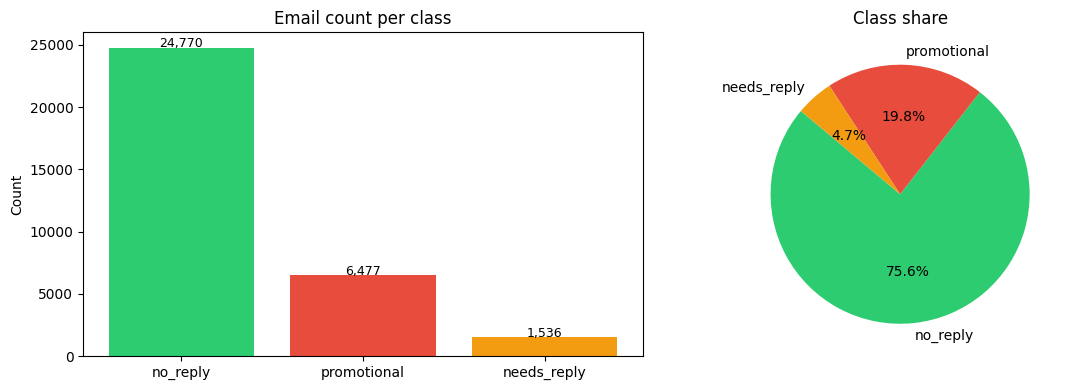

**Body length (words) per class** — `needs_reply` emails tend to be the longest (mean 549 words), which makes sense since they're real conversations. The `no_reply` median is much lower than the mean (166 vs 410), suggesting a long tail of automated notifications with very short bodies.

,mean,median,min,max
label,,,,
needs_reply,549,281,1,5677
no_reply,410,166,0,15155
promotional,471,391,9,4869


**HTML ratio per class** — promotional emails are almost entirely HTML templates (median 0.95), while `needs_reply` emails have a lower ratio (0.75), reflecting the fact that real human correspondence has more visible text relative to markup.

,mean,median
label,,
needs_reply,0.700,0.753
no_reply,0.839,0.917
promotional,0.936,0.949


**Structural features — mean per class** — for binary features, the value can be read as the proportion of emails where the feature is present. A few things stand out: `is_reply_chain` is 0.68 for `needs_reply` but 0.00 for promotional — makes sense, promos are never replies. `has_unsubscribe` is the opposite: 0.86 for promotional, 0.00 for `needs_reply`. `is_cc` is 0.38 for `needs_reply` — people who CC me are more likely expecting a response. These should be strong signals for the model.

label,needs_reply,no_reply,promotional
is_directly_to_me,0.480,0.297,0.235
is_cc,0.380,0.120,0.000
has_unsubscribe,0.000,0.351,0.857
body_length,63.727,294.679,359.762
link_count,0.531,0.328,0.087
is_reply_chain,0.681,0.110,0.000
html_processed,0.980,0.980,1.000
html_ratio,0.700,0.839,0.936
has_signature,0.158,0.096,0.036


In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#2ecc71", "#e74c3c", "#f39c12"]
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Email count per class")
axes[0].set_ylabel("Count")
for i, (cls, v) in enumerate(counts.items()):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=9)

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140)
axes[1].set_title("Class share")

plt.tight_layout()
plt.show()

from IPython.display import display, Markdown

display(Markdown(
    "**Body length (words) per class** — `needs_reply` emails tend to be the longest "
    "(mean 549 words), which makes sense since they're real conversations. "
    "The `no_reply` median is much lower than the mean (166 vs 410), suggesting a long "
    "tail of automated notifications with very short bodies."
))
display(
    df.groupby("label")["body"]
    .apply(lambda x: x.str.split().str.len())
    .groupby(level=0)
    .agg(["mean", "median", "min", "max"])
    .round(0)
    .astype(int)
)

display(Markdown(
    "**HTML ratio per class** — promotional emails are almost entirely HTML templates "
    "(median 0.95), while `needs_reply` emails have a lower ratio (0.75), reflecting "
    "the fact that real human correspondence has more visible text relative to markup."
))
display(
    df.groupby("label")["html_ratio"]
    .agg(["mean", "median"])
    .round(3)
)

display(Markdown(
    "**Structural features — mean per class** — for binary features, the value can be "
    "read as the proportion of emails where the feature is present. A few things stand out: "
    "`is_reply_chain` is 0.68 for `needs_reply` but 0.00 for promotional — makes sense, "
    "promos are never replies. `has_unsubscribe` is the opposite: 0.86 for promotional, "
    "0.00 for `needs_reply`. `is_cc` is 0.38 for `needs_reply` — people who CC me are more "
    "likely expecting a response. These should be strong signals for the model."
))
display(
    df.groupby("label")[STRUCTURAL_COLS]
    .mean()
    .round(3)
    .T
)


### Qualitative examples per class

Below I will show two representative emails for each class — one from the Polish (Econverse) inbox and one from the English (Minerva) inbox where available — to illustrate what the model is learning to distinguish. Polish subjects and bodies are followed by an English translation in *italics*.

Names of third parties have been replaced with `[ANONYMIZED_NAME]` to protect the privacy of individuals who appear in the correspondence. My own name and email are left intact since this is my personal data archive.

#### `needs_reply`

**Polish example**
- **Subject:** Re: faktura Venture Cafe Warsaw; eConverse — *Re: invoice Venture Cafe Warsaw; eConverse*
- **Body:** Panie Hubercie, Proszę o doprowadzenie niniejszej sprawy do końca. Powinniście Państwo wystawić dla Fundacji VCW fakturę barterową na kwotę 5000 zł netto oraz opłacić kwotę vat w wysokości 1150 zł wynikającą z faktury 22/12/2022. Pozdrawiam, [ANONYMIZED_NAME]
- *Body translation: Mr. Hubert, please bring this matter to a close. You should issue a barter invoice for 5000 PLN net to the VCW Foundation and pay the VAT amount of 1150 PLN resulting from invoice 22/12/2022. Best regards, [ANONYMIZED_NAME]*

**English example**
- **Subject:** Faktura - asap — *Invoice - asap*
- **Body:** Pls - identyfikatory i smycze dla teamu na WSC
- *Body translation: Pls — IDs and lanyards for the team at WSC*

#### `no_reply`

**Polish example**
- **Subject:** Re: NDA [ANONYMIZED_NAME] — *Re: [ANONYMIZED_NAME]'s NDA*
- **Body:** On Wed, Jul 27, 2022 at 11:03 AM <hubertpysklo@econverse.org> wrote: Podpiszesz i odeślesz? Może być cyfrowo HP
- *Body translation: Will you sign and send it back? Can be digital. HP*

**English example**
- **Subject:** ClickUp Verification Code: 8283
- **Body:** Verify your account 8283 Go to verify © 2022 ClickUp | San Diego, CA

#### `promotional`

**Polish example**
- **Subject:** Pobierz bezpłatny ebook i odbierz rabat na Comarch IBARD! — *Download a free ebook and get a discount on Comarch IBARD!*
- **Body:** Pobierz bezpłatny ebook i odbierz rabat na Comarch IBARD! Zapisz się na webinar o zmianach w Kodeksie pracy Jeżeli materiał nie wyświetla się poprawnie, zobacz go w przeglądarce
- *Body translation: Download a free ebook and get a discount on Comarch IBARD! Sign up for a webinar about changes in the Labour Code. If the content does not display correctly, view it in your browser.*

**English example**
- **Subject:** ClickUp Release Notes are back!
- **Body:** Release Notes are back with Default Task Templates, Automation Manager Enhancements, and Sprint Folder Settings, and more! Let's make the world more productive, together


## Thread-aware group split

A naive random train/test split risks data leakage - emails from the same thread can end up in both sets, and they share subject lines, writing style, and topic. Since the model would effectively see parts of the test data during training, metrics would be inflated.

To prevent this, we use `GroupShuffleSplit` with `groups=thread_id`, ensuring that **all emails from a given thread appear in either train or test, never both**.

In [91]:
from sklearn.model_selection import GroupShuffleSplit

X_text_raw = df["text"].values
X_struct   = df[STRUCTURAL_COLS].fillna(0).values
y          = df["label"].values
groups     = df["thread_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_train, idx_test = next(gss.split(X_text_raw, y, groups=groups))

X_text_train = X_text_raw[idx_train]
X_text_test  = X_text_raw[idx_test]
X_struct_train = X_struct[idx_train]
X_struct_test  = X_struct[idx_test]
y_train = y[idx_train]
y_test  = y[idx_test]

train_threads = set(groups[idx_train])
test_threads  = set(groups[idx_test])
overlap = train_threads & test_threads


display(Markdown(
    f"**Split summary** — {len(train_threads):,} threads in train, "
    f"{len(test_threads):,} in test, **{len(overlap)} overlap** ."
))

split_df = pd.DataFrame({
    "Train": pd.Series(y_train).value_counts(),
    "Test": pd.Series(y_test).value_counts(),
})
split_df.loc["TOTAL"] = split_df.sum()
split_df["Train %"] = (split_df["Train"] / split_df.loc["TOTAL", "Train"] * 100).round(1)
split_df["Test %"]  = (split_df["Test"]  / split_df.loc["TOTAL", "Test"]  * 100).round(1)
split_df = split_df[["Train", "Train %", "Test", "Test %"]].astype({"Train": int, "Test": int})
display(split_df)

**Split summary** — 21,430 threads in train, 5,358 in test, **0 overlap** .

,Train,Train %,Test,Test %
no_reply,19853,75.8,4917,74.7
promotional,5122,19.5,1355,20.6
needs_reply,1230,4.7,306,4.7
TOTAL,26205,100.0,6578,100.0


The class proportions are roughly preserved between train and test, which is what we want. The key challenge is `needs_reply` — it's only ~5% of the data in both splits, meaning the model will see relatively few positive examples during training. This is why we use auto-balancers in Sklearn that oversample underrepresented examples and undersample the majority class, and adjust measurement metrics, for example macro F1 as our main scoring metric — accuracy alone would be misleading since a model that predicts `no_reply` for everything would already hit ~76%.

# Model Selection

## Feature preparation — TF-IDF + structural features

Before we can train any model, we need to convert the raw text into a numerical representation. I use TF-IDF (Term Frequency–Inverse Document Frequency) for this.

The idea behind TF-IDF is simple - a word's importance in a document should increase with how often it appears in that document (term frequency), but decrease if it appears in many documents across the corpus (inverse document frequency). Words like "the" or "email" appear everywhere and get low weight, while words like "faktura" (invoice) or "urgent" that appear frequently in specific emails but rarely overall get high weight.

Formally, for a term $t$ in document $d$ within a corpus $D$:

$$\text{TF}(t, d) = \frac{\text{count of } t \text{ in } d}{\text{total terms in } d}$$

$$\text{IDF}(t, D) = \log \frac{|D|}{1 + |\{d \in D : t \in d\}|}$$

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

The result is a sparse matrix where each row is an email and each column is a word (or bigram) from the vocabulary. Most entries are zero because any given email only contains a small fraction of the total vocabulary.

I use the following settings in `TfidfVectorizer`:
- `max_features=5000` — keep only the 5,000 most informative terms to limit dimensionality
- `ngram_range=(1, 2)` — include both single words and two-word phrases (e.g. "best regards" as a single feature, which helps capture signature patterns)
- `min_df=2` — exclude terms that appear in only one document, since they're likely noise (typos, unique names, etc.)

The resulting TF-IDF matrix is then horizontally stacked with the 9 structural features from prior sections, giving us a combined feature matrix of ~5,009 dimensions per email.

---

## I will evaluate three classifiers of increasing complexity for this task:

---

## Logistic Regression

Logistic regression models the probability that an input $\mathbf{x}$ belongs to class $k$ using the softmax function (multinomial case):

$$P(y = k \mid \mathbf{x}) = \frac{\exp(\mathbf{w}_k^\top \mathbf{x} + b_k)}{\sum_{j=1}^{K} \exp(\mathbf{w}_j^\top \mathbf{x} + b_j)}$$

Training minimises the cross-entropy loss with L2 regularisation:

$$\mathcal{L} = -\sum_{i=1}^{N} \log P(y_i \mid \mathbf{x}_i) + \frac{\lambda}{2} \|\mathbf{w}\|^2$$

The first term is the cross-entropy loss — it measures how far off the model's predicted probabilities are from the true labels. Minimising it pushes the model to assign high probability to the correct class for each training example. The second term is L2 regularisation (also called ridge penalty) — it penalises large weights by adding the squared magnitude of the weight vector to the loss. This prevents the model from overfitting to the training data by keeping the coefficients small, which is especially important when we have 5,000+ TF-IDF features. The hyperparameter $\lambda$ (controlled by $C = 1/\lambda$ in scikit-learn) determines the trade-off between fitting the data well and keeping weights small — we tune it via cross-validation in the next sec.

We use `class_weight="balanced"` to up-weight the minority class — this effectively multiplies the loss contribution of each `needs_reply` example by a factor proportional to how underrepresented it is, so the model doesn't just learn to predict `no_reply` for everything.

---

## Multinomial Naive Bayes

Naive Bayes applies Bayes' theorem with the conditional independence assumption:

$$P(y = k \mid \mathbf{x}) \propto P(y = k) \prod_{j=1}^{d} P(x_j \mid y = k)$$

For TF-IDF features, the multinomial model estimates:

$$P(x_j \mid y = k) = \frac{N_{kj} + \alpha}{N_k + \alpha d}$$

where $\alpha$ is the Laplace smoothing parameter. Without it, if a word never appears in a given class during training, its probability would be zero — and since Naive Bayes multiplies all the word probabilities together, a single zero would make the entire class probability zero regardless of all other features. Laplace smoothing fixes this by adding a small count $\alpha$ to every word in every class, so no probability is ever exactly zero. Higher $\alpha$ means more smoothing (probabilities pushed closer to uniform), lower $\alpha$ means the model trusts the training counts more. We tune this in Section 6.

This model requires non-negative inputs, so structural features are scaled to $[0, 1]$ with `MinMaxScaler`.

---

## Multi-Layer Perceptron (MLP)

The MLP is a feedforward neural network — unlike Logistic Regression (which is essentially a single linear layer + softmax), the MLP stacks multiple layers of learned transformations, which allows it to capture non-linear relationships between features. For example, it could learn that the combination of `is_reply_chain=1` AND `body_length < 50` is a strong signal for `needs_reply`, even if neither feature alone is sufficient.

I use an architecture with two hidden layers (256 → 128 neurons). Each layer applies a linear transformation followed by a non-linear activation:

$$\mathbf{h}^{(l)} = \text{ReLU}(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)})$$

where $\text{ReLU}(z) = \max(0, z)$ is the activation function — it simply zeroes out negative values and passes positive values through unchanged. ReLU is the standard choice for hidden layers because it's fast to compute and avoids the vanishing gradient problem that older activations (like sigmoid) suffer from. The output layer uses softmax to convert the final layer's raw scores into class probabilities.

I train it with the Adam optimiser (Adaptive Moment Estimation). The basic idea of any gradient-based optimiser is to compute how much the loss would change if we nudged each weight slightly (the gradient), then update weights in the direction that reduces the loss. What makes Adam special is that it maintains two running averages for each weight:

- A momentum term (exponential moving average of past gradients) — this helps the optimiser keep moving in a consistent direction instead of oscillating
- A velocity term (exponential moving average of past squared gradients) — this adapts the learning rate per-parameter, so features that get frequent updates take smaller steps and rare features take larger steps

This makes Adam much faster to converge than plain gradient descent, and it works well out of the box without much tuning of the learning rate.

I also use early stopping with patience = 5 — during training, 10% of the training data is held out as a validation set, and if the validation score doesn't improve for 5 consecutive epochs, training stops. This prevents overfitting: the model trains just long enough to learn the useful patterns but stops before it starts memorising the training data. L2 regularisation ($\alpha = 10^{-4}$) provides an additional guard against overfitting by penalising large weights, same idea as in Logistic Regression.


In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

# fit_transform learns the vocabulary + IDF weights from train; transform applies
# the same vocabulary to test without re-learning (prevents data leakage).
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_tfidf_train = vectorizer.fit_transform(X_text_train)
X_tfidf_test  = vectorizer.transform(X_text_test)

# Scale structural features to [0, 1] so they're on the same scale as TF-IDF.
# Without this, features like body_length (0–15k) dominate the regularisation
# penalty and cause lbfgs convergence issues in Logistic Regression.
scaler = MinMaxScaler()
X_struct_train_scaled = scaler.fit_transform(X_struct_train)
X_struct_test_scaled  = scaler.transform(X_struct_test)

# Stack scaled structural features with TF-IDF into a single sparse matrix.
X_train_combined = hstack([X_tfidf_train, csr_matrix(X_struct_train_scaled)])
X_test_combined  = hstack([X_tfidf_test,  csr_matrix(X_struct_test_scaled)])

print(f"TF-IDF vocabulary size : {len(vectorizer.vocabulary_):,}")
print(f"Structural features    : {len(STRUCTURAL_COLS)}")
print(f"Combined feature dim   : {X_train_combined.shape[1]:,}")

TF-IDF vocabulary size : 5,000
Structural features    : 9
Combined feature dim   : 5,009


# Model Training

We will tune hyperparameters and train all three models using 5-fold GroupKFold cross-validation on the training set. GroupKFold ensures that emails from the same thread never appear in both the training and validation folds within a CV split — the same constraint we enforce in the train/test split.

For each model I will perform a grid search over a small set of hyperparameters, scored by macro F1 (which weights each class equally and is appropriate for our imbalanced dataset). `GridSearchCV` with `refit=True` automatically refits the best configuration on the full training set after the search completes.

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, GroupKFold

# Extract thread groups for training samples — needed by GroupKFold to ensure
# emails from the same thread stay together within each CV fold.
groups_train = groups[idx_train]
gkf = GroupKFold(n_splits=5)

# Grid search over C (inverse regularisation strength): small C = heavy
# regularisation (simpler model), large C = less regularisation (fits data harder).
lr_grid = GridSearchCV(
    LogisticRegression(solver="lbfgs", class_weight="balanced",
                       max_iter=10000, random_state=42),
    param_grid={"C": [0.01, 0.1, 1, 10]},
    cv=gkf,
    scoring="f1_macro",
    refit=True,   # automatically refit best params on full training set
    n_jobs=-1,    # parallelise across all CPU cores
)
lr_grid.fit(X_train_combined, y_train, groups=groups_train)
lr_model = lr_grid.best_estimator_

print("Logistic Regression — cross-validation results")
means = lr_grid.cv_results_["mean_test_score"]
stds  = lr_grid.cv_results_["std_test_score"]
for param, m, s in zip(lr_grid.cv_results_["params"], means, stds):
    print(f"  C={param['C']:<6}  macro F1 = {m:.4f} ± {s:.4f}")
print(f"\n  Best: C={lr_grid.best_params_['C']}  (macro F1 = {lr_grid.best_score_:.4f})")

Logistic Regression — cross-validation results
  C=0.01    macro F1 = 0.6069 ± 0.0081
  C=0.1     macro F1 = 0.6832 ± 0.0098
  C=1       macro F1 = 0.7211 ± 0.0109
  C=10      macro F1 = 0.7239 ± 0.0165

  Best: C=10  (macro F1 = 0.7239)


In [98]:
from sklearn.naive_bayes import MultinomialNB

# NB uses the same combined matrix as LR/MLP — structural features were already
# scaled to [0, 1] in the feature preparation cell, which satisfies MultinomialNB's
# non-negative input requirement.
X_train_nb = X_train_combined
X_test_nb  = X_test_combined

# Grid search over alpha (Laplace smoothing): small alpha = trusts the raw
# counts more, large alpha = smooths probabilities toward uniform.
nb_grid = GridSearchCV(
    MultinomialNB(),
    param_grid={"alpha": [0.01, 0.1, 0.5, 1.0, 2.0]},
    cv=gkf,
    scoring="f1_macro",
    refit=True,
    n_jobs=-1,
)
nb_grid.fit(X_train_nb, y_train, groups=groups_train)
nb_model = nb_grid.best_estimator_

print("Naive Bayes — cross-validation results:")
means = nb_grid.cv_results_["mean_test_score"]
stds  = nb_grid.cv_results_["std_test_score"]
for param, m, s in zip(nb_grid.cv_results_["params"], means, stds):
    print(f"  alpha={param['alpha']:<6}  macro F1 = {m:.4f} ± {s:.4f}")
print(f"\n  Best: alpha={nb_grid.best_params_['alpha']}  (macro F1 = {nb_grid.best_score_:.4f})")

Naive Bayes — cross-validation results:
  alpha=0.01    macro F1 = 0.6668 ± 0.0105
  alpha=0.1     macro F1 = 0.6650 ± 0.0106
  alpha=0.5     macro F1 = 0.6609 ± 0.0118
  alpha=1.0     macro F1 = 0.6599 ± 0.0144
  alpha=2.0     macro F1 = 0.6371 ± 0.0115

  Best: alpha=0.01  (macro F1 = 0.6668)


In [99]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

# MLPClassifier needs integer labels, not strings — LabelEncoder maps
# class names to 0, 1, 2 so the MLP's softmax output layer works correctly.
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Grid search over architecture size and L2 penalty (alpha).
# early_stopping holds out 10% of training data as internal validation —
# if the score doesn't improve for 5 epochs, training halts to prevent overfitting.
mlp_grid = GridSearchCV(
    MLPClassifier(
        activation="relu", solver="adam", batch_size=256,
        max_iter=100, random_state=42,
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=5, verbose=False,
    ),
    param_grid={
        "hidden_layer_sizes": [(256, 128), (128, 64), (512, 256, 128)],
        "alpha": [1e-5, 1e-4, 1e-3],
    },
    cv=gkf,
    scoring="f1_macro",
    refit=True,
    n_jobs=-1,
)
mlp_grid.fit(X_train_combined, y_train_enc, groups=groups_train)
mlp_model = mlp_grid.best_estimator_

print("MLP — cross-validation results:")
means = mlp_grid.cv_results_["mean_test_score"]
stds  = mlp_grid.cv_results_["std_test_score"]
for param, m, s in zip(mlp_grid.cv_results_["params"], means, stds):
    print(f"  layers={str(param['hidden_layer_sizes']):<12s}  "
          f"alpha={param['alpha']:<8}  macro F1 = {m:.4f} ± {s:.4f}")
bp = mlp_grid.best_params_
print(f"\n  Best: layers={bp['hidden_layer_sizes']}, alpha={bp['alpha']}  "
      f"(macro F1 = {mlp_grid.best_score_:.4f})")

Label mapping: {'needs_reply': np.int64(0), 'no_reply': np.int64(1), 'promotional': np.int64(2)}
MLP — cross-validation results:
  layers=(256, 128)    alpha=1e-05     macro F1 = 0.7021 ± 0.0075
  layers=(128, 64)     alpha=1e-05     macro F1 = 0.6525 ± 0.0433
  layers=(512, 256, 128)  alpha=1e-05     macro F1 = 0.6837 ± 0.0288
  layers=(256, 128)    alpha=0.0001    macro F1 = 0.7000 ± 0.0058
  layers=(128, 64)     alpha=0.0001    macro F1 = 0.6433 ± 0.0302
  layers=(512, 256, 128)  alpha=0.0001    macro F1 = 0.6810 ± 0.0292
  layers=(256, 128)    alpha=0.001     macro F1 = 0.6865 ± 0.0177
  layers=(128, 64)     alpha=0.001     macro F1 = 0.6610 ± 0.0468
  layers=(512, 256, 128)  alpha=0.001     macro F1 = 0.6620 ± 0.0469

  Best: layers=(256, 128), alpha=1e-05  (macro F1 = 0.7021)


# Predictions & Performance Metrics

We will now generate predictions on the held-out test set and compute classification reports and macro F1 scores.

### Logistic Regression

,precision,recall,f1-score,support
needs_reply,0.32,0.67,0.43,306.00
no_reply,0.95,0.84,0.89,4917.00
promotional,0.77,0.90,0.83,1355.00
accuracy,0.85,0.85,0.85,0.85
macro avg,0.68,0.80,0.72,6578.00
weighted avg,0.88,0.85,0.86,6578.00


### Naive Bayes

,precision,recall,f1-score,support
needs_reply,0.27,0.72,0.39,306.00
no_reply,0.95,0.72,0.82,4917.00
promotional,0.61,0.92,0.74,1355.00
accuracy,0.76,0.76,0.76,0.76
macro avg,0.61,0.79,0.65,6578.00
weighted avg,0.85,0.76,0.78,6578.00


### MLP

,precision,recall,f1-score,support
needs_reply,0.48,0.13,0.20,306.00
no_reply,0.90,0.96,0.93,4917.00
promotional,0.87,0.81,0.84,1355.00
accuracy,0.89,0.89,0.89,0.89
macro avg,0.75,0.63,0.66,6578.00
weighted avg,0.87,0.89,0.88,6578.00


### Macro F1 comparison

,Macro F1
Model,
Logistic Regression,0.7193
Naive Bayes,0.6498
MLP,0.6563


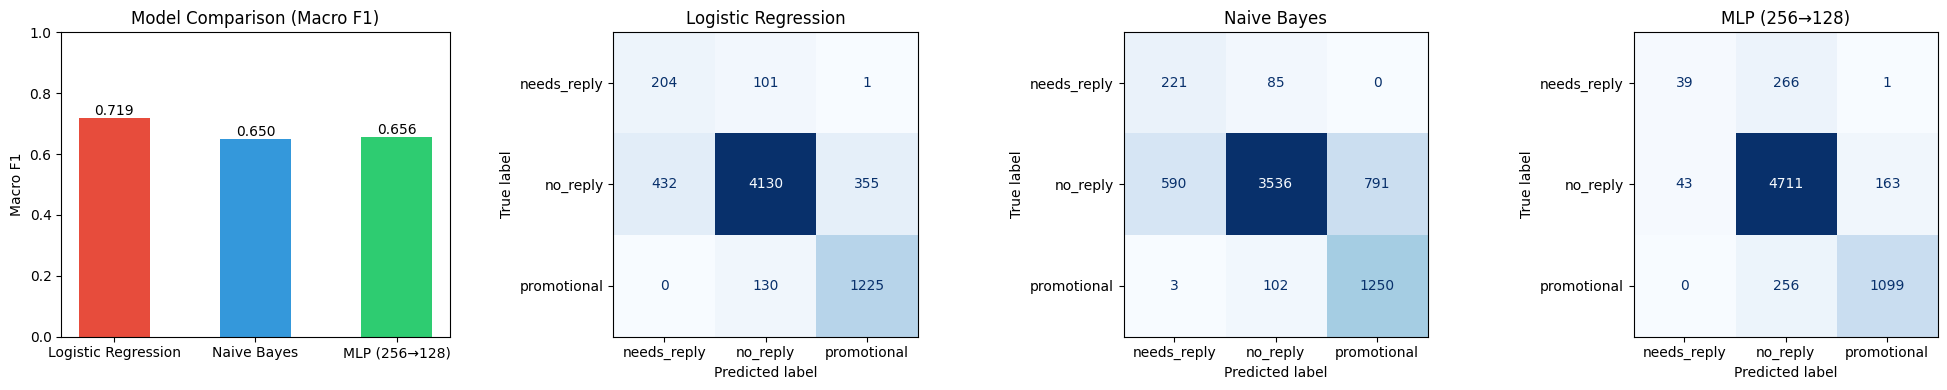

In [101]:
from sklearn.metrics import classification_report, f1_score
from IPython.display import display, Markdown

y_pred_lr  = lr_model.predict(X_test_combined)
y_pred_nb  = nb_model.predict(X_test_nb)
y_pred_mlp = le.inverse_transform(mlp_model.predict(X_test_combined))

# Build per-model classification reports as DataFrames for clean rendering
models = {
    "Logistic Regression": (y_test, y_pred_lr),
    "Naive Bayes":         (y_test, y_pred_nb),
    "MLP":                 (y_test, y_pred_mlp),
}

for name, (y_true, y_pred) in models.items():
    report = pd.DataFrame(
        classification_report(y_true, y_pred, output_dict=True)
    ).T
    display(Markdown(f"### {name}"))
    display(report.round(2))

# Summary comparison table
f1_lr  = f1_score(y_test, y_pred_lr,  average="macro")
f1_nb  = f1_score(y_test, y_pred_nb,  average="macro")
f1_mlp = f1_score(y_test, y_pred_mlp, average="macro")

display(Markdown("### Macro F1 comparison"))
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "MLP"],
    "Macro F1": [f1_lr, f1_nb, f1_mlp],
}).set_index("Model").round(4)
display(comparison)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Macro F1 bar chart ---
model_names = ["Logistic Regression", "Naive Bayes", "MLP (256→128)"]
f1_scores   = [f1_lr, f1_nb, f1_mlp]
bar_colors  = ["#e74c3c", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

bars = axes[0].bar(model_names, f1_scores, color=bar_colors, width=0.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Macro F1")
axes[0].set_title("Model Comparison (Macro F1)")
for bar, score in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2, score + 0.01,
                 f"{score:.3f}", ha="center", fontsize=10)

# --- Confusion matrices ---
class_names = sorted(df["label"].unique())
for ax, name, y_pred in zip(
    axes[1:],
    model_names,
    [y_pred_lr, y_pred_nb, y_pred_mlp],
):
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

### Discussion

Logistic Regression is the clear winner with a macro F1 of 0.72, outperforming both Naive Bayes (0.65) and the MLP (0.66).

The main challenge across all models is `needs_reply` — it's the smallest class (~5%) and the hardest to classify. LR handles it best with 0.67 recall (catches 67% of emails that actually need a reply), though at the cost of low precision (0.32) — meaning it over-predicts `needs_reply`, which is an acceptable trade-off for this use case (better to flag too many than miss important emails). The MLP has the opposite problem: high precision (0.48) but very low recall (0.13), meaning it almost never predicts `needs_reply` despite using `class_weight` balancing and early stopping. This is visible in the confusion matrix where the MLP misclassifies most `needs_reply` emails as `no_reply`.

For `no_reply` and `promotional`, all three models perform well (F1 > 0.74). This makes sense — promotional emails have strong signals (high `has_unsubscribe`, high `html_ratio`, zero `is_reply_chain`) and `no_reply` is the majority class with plenty of training examples.

The fact that a simple linear model (LR) beats the MLP is not surprising for this task — with TF-IDF features, the decision boundary between classes is largely linear (certain words and structural features push toward certain classes), and the MLP's extra capacity doesn't help much when the training data for the rare class is limited.

### Error analysis — representative examples

Looking at specific misclassifications from Logistic Regression helps explain where the model struggles:

**`needs_reply` predicted as `no_reply`** — "Re: Warsztat KBH x Econverse" (*Re: Workshop KBH x Econverse*). The body asks me to provide a photo and a short bio, and includes a LinkedIn link. This is clearly a request that needs action, but the email is short and contains several tokens that also appear in `no_reply` emails (LinkedIn links, quoted replies). The model likely doesn't have enough `needs_reply` training examples with this pattern to learn it.

**`no_reply` predicted as `needs_reply`** — "Re: Dysk i skrzynka mailowa @ econverse" (*Re: Disk and mailbox @ econverse*). This is a reply from a colleague saying "hey, great tutorial, I think I have everything connected" — no action needed from me. But it's a reply chain (`Re:`), it mentions my name, it's short, and it's a direct human message — all features that strongly correlate with `needs_reply`. The model can't distinguish "informational reply" from "reply expecting action" without understanding the semantics.

**`promotional` predicted as `no_reply`** — "Alex Terrana has invited you to work with them in Slack". This is an automated Slack invitation which we labeled as promotional, but it looks nothing like a typical marketing email — no `has_unsubscribe` header, no heavy HTML template, no promotional keywords. It's essentially an edge case between automated notifications and promotional content.


## Model interpretability

To understand *what* the models learned, we can inspect their internal feature weights. For Naive Bayes, we look at the log-probabilities of each feature given each class — features with the highest log-probability are the ones the model considers most characteristic of that class. For Logistic Regression, we examine the learned coefficients — positive coefficients push toward a class, negative ones push away. The MLP, being a non-linear model with hidden layers, does not lend itself to this kind of direct interpretation.


Looking at the most important features for each model confirms the models are learning sensible patterns from the data:

For Naive Bayes, the most distinctive words per class (ranked by how much their log-probability in one class exceeds the cross-class mean) make intuitive sense: `needs_reply` is dominated by business terms like "umowa" (contract), "faktura" (invoice), and organization-specific bigrams like "re econverse" and "ai consensus". The `no_reply` class is driven by order-confirmation tokens from a bakery I frequently ordered from ("cukiernia zagrodnicza", "nr zamówienia") — these are automated receipts I never replied to. `promotional` features are classic marketing signals: "czytaj więcej" (read more), "see tickets", newsletter-related terms, and newspaper subscription tokens ("wyborcza").

For Logistic Regression, the top positive and negative coefficients tell a similar story but with an interesting addition — the structural features show up prominently. `has_unsubscribe` is the strongest negative predictor for `needs_reply` (coeff: -5.97) and a strong positive predictor for `promotional` (+3.85), confirming what we saw in the EDA. `body_length` pushes toward `no_reply` (+4.16) and away from `promotional` (-4.74), which reflects the fact that automated notifications and personal emails tend to be longer than marketing templates once HTML is stripped. The word-level features also make sense: "wysłać" (to send), "bardzo" (very much), and "minerva" push toward `needs_reply`, while "unsubscribe", "manage preferences", and "sent by" push toward `promotional`.

The MLP, being a non-linear model with hidden layers, doesn't lend itself to this kind of per-feature interpretation — which is a well-known trade-off between expressiveness and interpretability in neural networks.

In [ ]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
n_text_features = len(feature_names)
all_feature_names = np.array(list(feature_names) + STRUCTURAL_COLS)

# Raw log-probabilities are dominated by common words that appear everywhere.
# Instead, we rank by how much a word's log-prob in one class exceeds
# the mean across all classes -- this reveals truly distinctive terms.
print("NAIVE BAYES — Most distinctive words per class")

log_probs_text = nb_model.feature_log_prob_[:, :n_text_features]
mean_log_probs = log_probs_text.mean(axis=0)

for i, cls in enumerate(nb_model.classes_):
    diff = log_probs_text[i] - mean_log_probs
    top_indices = diff.argsort()[-10:][::-1]
    print(f"  [{cls}]")
    for j in top_indices:
        print(f"    {feature_names[j]:<30s}  diff: {diff[j]:+.4f}  "
              f"(class: {log_probs_text[i][j]:.4f}, mean: {mean_log_probs[j]:.4f})")
    print()

print("LOGISTIC REGRESSION — Top features per class")
print("(positive coeff = pushes toward this class,")
print(" negative coeff = pushes away from this class)\n")

for i, cls in enumerate(lr_model.classes_):
    coefs = np.asarray(lr_model.coef_[i]).flatten()
    top_pos = coefs.argsort()[-5:][::-1]
    top_neg = coefs.argsort()[:5]

    print(f"  [{cls}] — Top 5 features for this class:")
    for j in top_pos:
        print(f"    {all_feature_names[j]:<30s}  coeff: {coefs[j]:+.4f}")

    print(f"  [{cls}] — Top 5 features against this class:")
    for j in top_neg:
        print(f"    {all_feature_names[j]:<30s}  coeff: {coefs[j]:+.4f}")
    print()



NAIVE BAYES — Most distinctive words per class
  [needs_reply]
    re econverse                    diff: +4.0236  (class: -5.5935, mean: -9.6171)
    quoted reply                    diff: +3.6166  (class: -3.5942, mean: -7.2108)
    quoted                          diff: +3.5268  (class: -3.5984, mean: -7.1252)
    umowa                           diff: +3.4304  (class: -5.5300, mean: -8.9605)
    name email                      diff: +3.3867  (class: -6.1942, mean: -9.5808)
    students ai                     diff: +3.2530  (class: -7.1024, mean: -10.3554)
    fundacja econverse              diff: +3.1430  (class: -7.0550, mean: -10.1980)
    cze                             diff: +3.0391  (class: -7.7520, mean: -10.7911)
    aic                             diff: +2.9999  (class: -7.4940, mean: -10.4938)
    faktura                         diff: +2.9141  (class: -6.1350, mean: -9.0491)

  [no_reply]
    cukiernia                       diff: +4.6703  (class: -7.7173, mean: -12.3876)
    c

## Conclusions

1. Logistic Regression is the best model for this task (macro F1 = 0.72), beating both Naive Bayes (0.65) and the MLP (0.66). A simple linear model with good features outperforms a neural network here — the decision boundaries are largely linear with TF-IDF features, and the MLP's extra capacity doesn't help when there's limited rare-class data.
2. `needs_reply` remains the hardest class — it's only ~5% of the dataset, and distinguishing "emails that need action" from "informational replies" often requires semantic understanding that TF-IDF can't capture.
3. `promotional` is the easiest to classify — structural features like `has_unsubscribe`, `html_ratio`, and `is_reply_chain` provide very strong signals that align well with Gmail's own labeling.
4. Naive Bayes struggles because the conditional independence assumption is too strong — in reality TF-IDF features and structural metadata are correlated (e.g. emails with "unsubscribe" also tend to have high `html_ratio` and `has_unsubscribe=1`).
5. The thread-aware group split was essential — without it, emails from the same thread could leak between train and test, artificially inflating metrics.

# Executive Summary

## Pipeline overview

```
Gmail mbox exports (PL + EN)
        │
        ▼
  Data Ingestion
  (MIME decode, HTML-first body extraction, metadata)
        │
        ▼
  Labeling (trigger-based)
  needs_reply │ no_reply │ promotional
        │
        ▼
  Text Cleaning + Feature Engineering
  (clean_text, TF-IDF, structural features)
        │
        ▼
  Thread-aware Group Split (80/20)
        │
    ┌───┴───┐
    ▼       ▼
  Train    Test
    │       │
    ▼       ▼
  GroupKFold CV + Grid Search  →  Best models  →  Test set evaluation
```

## Summary

I built a pipeline that classifies ~33,000 incoming Gmail emails from my two accounts (Econverse business account in Polish and Minerva University student account in English) into three categories: `needs_reply`, `no_reply`, and `promotional`. The goal is to recreate Gmail's filtering intelligence so I can eventually apply it to my Outlook accounts, which have historically been bad at this.

The trickiest part was creating reliable labels. I used a trigger-based approach — only the single incoming email that directly preceded one of my sent replies gets labeled `needs_reply`. On top of that, I had to filter out automated senders (bounce notices, noreply addresses, email-tracking tools) that would otherwise contaminate the `needs_reply` class — this removed ~10% of false positives.

For features, I combined TF-IDF vectors (5,000 most informative unigrams and bigrams) with 9 structural features extracted from email metadata (things like `has_unsubscribe`, `is_reply_chain`, `html_ratio`). The structural features turned out to be very discriminative — for example, `has_unsubscribe` alone nearly separates promotional from non-promotional emails.

I evaluated three models — Logistic Regression, Multinomial Naive Bayes, and a two-layer MLP — using 5-fold GroupKFold cross-validation with grid search over key hyperparameters. Logistic Regression won with a macro F1 of 0.72, outperforming the MLP (0.66) and Naive Bayes (0.65). The main bottleneck is the `needs_reply` class at only ~5% of the data — the model catches 67% of emails that actually need a reply, but at the cost of some false positives.

## Shortcomings and possible improvements

- Class imbalance: `needs_reply` is rare (~5%). Techniques like SMOTE or focal loss could improve recall for this class, though they come with their own trade-offs (synthetic examples may not represent real email patterns well).
- Label noise: even after filtering known automated senders, some system-generated emails may still slip through. A manual review pass of the `needs_reply` set could further clean up the labels.
- Richer features: sender domain, time-of-day, reply latency history, and how often I correspond with a given sender could all add predictive power. These are readily available in the mbox data but I didn't extract them for this iteration.
- Better text representations: TF-IDF treats each word independently and can't capture semantics ("can you send this?" vs "I sent this" look similar in TF-IDF but mean very different things). Pre-trained multilingual models like sentence-BERT could help, especially since the corpus mixes Polish and English.
- The MLP underperformed expectations — experimenting with different architectures, learning rate schedules, or using class-weighted loss (instead of just early stopping) might help it compete with LR on the rare class.

# References

1. **scikit-learn** — Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12, pp. 2825–2830. https://scikit-learn.org/
2. **pandas** — McKinney, W. (2010). *Data Structures for Statistical Computing in Python.* SciPy 2010. https://pandas.pydata.org/
3. **BeautifulSoup** — Richardson, L. *Beautiful Soup Documentation.* https://www.crummy.com/software/BeautifulSoup/
4. **Python `mailbox` module** — https://docs.python.org/3/library/mailbox.html
5. **Python `email.header` module** — https://docs.python.org/3/library/email.header.html
6. **Google Takeout** — https://takeout.google.com/
7. **TF-IDF** — Salton, G. & Buckley, C. (1988). *Term-weighting approaches in automatic text retrieval.* Information Processing & Management, 24(5), pp. 513–523.
8. **Multinomial Naive Bayes** — Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval.* Cambridge University Press. Chapter 13.
9. **Adam optimiser** — Kingma, D. P. & Ba, J. (2015). *Adam: A Method for Stochastic Optimization.* ICLR 2015.